# Nested Cross-Validation

## Overview

Standard CV with hyperparameter tuning produces a biased performance estimate: the hyperparameters were chosen to maximise CV performance on the same folds used to evaluate it. This is **selection bias** — the reported CV error is optimistic.

**Nested CV** uses two independent CV loops to separate tuning from evaluation:

```
Outer loop (k_outer folds) — estimates generalisation performance
│
└── For each outer fold:
    ├── Outer training set → Inner loop (k_inner folds) — tunes hyperparameters
    │   └── Select best hyperparameters from inner CV
    └── Refit with best hyperparameters on outer training set
        └── Evaluate on outer validation fold → one unbiased performance estimate
```

The outer CV produces k_outer performance estimates. Their mean is an approximately unbiased estimate of the true generalisation error.

**When is the bias large enough to matter?**
- Small datasets (n < 500): often 2–10% AUC inflation with naive CV
- Large hyperparameter spaces: more candidates = more selection bias
- Small inner CV (k=5 with few outer folds): high variance amplifies bias

**Computational cost:** Nested CV with k_outer=5, k_inner=5, and 30 hyperparameter candidates requires 5 × 5 × 30 = 750 model fits. Use with fast models or parallelism.

---

## Setup

In [1]:
library(tidyverse)
library(ggplot2)
library(rsample)
library(recipes)
library(parsnip)
library(workflows)
library(tune)
library(dials)
library(yardstick)
library(patchwork)

set.seed(42)

n <- 300   # deliberately small to make selection bias visible
nested_data <- tibble(
  nitrate     = rnorm(n, 3, 1.2),
  water_qual  = rnorm(n, 6, 1.5),
  distance_km = rexp(n, 0.4),
  elevation   = rnorm(n, 200, 80),
  slope_pct   = abs(rnorm(n, 10, 5)),
  present     = factor(rbinom(n, 1,
                   plogis(-1 + 0.6*water_qual - 0.7*nitrate - 0.2*distance_km)),
                   levels=c(0,1), labels=c("absent","present"))
)

cat(sprintf("n=%d | Prevalence: %.1f%%\n",
            n, mean(nested_data$present=="present")*100))

Warning message:
"package 'tidyverse' was built under R version 4.4.3"
Warning message:
"package 'ggplot2' was built under R version 4.4.3"
Warning message:
"package 'purrr' was built under R version 4.4.3"
Warning message:
"package 'dplyr' was built under R version 4.4.3"
Warning message:
"package 'stringr' was built under R version 4.4.3"
── Attaching core tidyverse packages ──────────────────────── tidyverse 2.0.0 ──
✔ dplyr     1.2.0     ✔ readr     2.1.5
✔ forcats   1.0.0     ✔ stringr   1.6.0
✔ ggplot2   4.0.2     ✔ tibble    3.2.1
✔ lubridate 1.9.3     ✔ tidyr     1.3.1
✔ purrr     1.2.1     
── Conflicts ────────────────────────────────────────── tidyverse_conflicts() ──
✖ dplyr::filter() masks stats::filter()
✖ dplyr::lag()    masks stats::lag()
ℹ Use the conflicted package (<http://conflicted.r-lib.org/>) to force all conflicts to become errors
Warning message:
"package 'rsample' was built under R version 4.4.3"
Warning message:
"package 'recipes' was built under R version 4.

n=300 | Prevalence: 45.3%


---

## Step 1: Naive CV (Demonstrates Optimistic Bias)

In [2]:
rec <- recipe(present ~ nitrate + water_qual + distance_km + elevation + slope_pct,
              data=nested_data) %>%
  step_normalize(all_numeric_predictors())

rf_spec <- rand_forest(
  mode  = "classification",
  trees = 300,
  mtry  = tune(),
  min_n = tune()
) %>% set_engine("ranger", seed=42)

wf <- workflow() %>% add_recipe(rec) %>% add_model(rf_spec)

# Naive CV: tune on the same folds used to evaluate
cv_folds_naive <- vfold_cv(nested_data, v=5, strata=present)

tune_grid_small <- grid_regular(
  mtry(range=c(1, 5)), min_n(range=c(2, 20)), levels=c(3, 3)
)

naive_results <- tune_grid(
  wf, resamples=cv_folds_naive,
  grid=tune_grid_small, metrics=metric_set(roc_auc)
)

best_naive <- select_best(naive_results, metric="roc_auc")
naive_auc  <- show_best(naive_results, metric="roc_auc", n=1)$mean
cat(sprintf("Naive CV AUC (optimistic): %.4f\n", naive_auc))

Naive CV AUC (optimistic): 0.7543


---

## Step 2: Nested CV (Unbiased Estimate)

In [3]:
# Outer CV: 5 folds for performance estimation
outer_folds <- vfold_cv(nested_data, v=5, strata=present)

# For each outer fold: tune on outer training set using inner CV,
# then evaluate the best model on the outer validation fold

nested_auc_per_fold <- map_dfr(
  seq_len(nrow(outer_folds)), function(i) {
    outer_split   <- outer_folds$splits[[i]]
    outer_train   <- analysis(outer_split)
    outer_val     <- assessment(outer_split)

    # Inner CV: 5 folds within the outer training set
    inner_folds <- vfold_cv(outer_train, v=5, strata=present)

    # Tune hyperparameters on the inner folds
    inner_results <- tune_grid(
      wf,
      resamples = inner_folds,
      grid      = tune_grid_small,
      metrics   = metric_set(roc_auc),
      control   = control_grid(verbose=FALSE)
    )

    # Best hyperparameters from inner CV
    best_inner <- select_best(inner_results, metric="roc_auc")

    # Refit on full outer training set with best hyperparameters
    final_wf   <- finalize_workflow(wf, best_inner)
    final_fit  <- fit(final_wf, data=outer_train)

    # Evaluate on the outer validation fold (never seen during tuning)
    preds <- augment(final_fit, new_data=outer_val)
    auc   <- roc_auc(preds, truth=present, .pred_present,
                     event_level="second")$.estimate

    tibble(
      outer_fold    = i,
      best_mtry     = best_inner$mtry,
      best_min_n    = best_inner$min_n,
      auc           = auc
    )
  }
)

print(nested_auc_per_fold)

nested_auc_mean <- mean(nested_auc_per_fold$auc)
nested_auc_se   <- sd(nested_auc_per_fold$auc) / sqrt(nrow(nested_auc_per_fold))

cat(sprintf("\nNested CV AUC (unbiased): %.4f ± %.4f SE\n",
            nested_auc_mean, nested_auc_se))
cat(sprintf("Naive CV AUC (optimistic): %.4f\n", naive_auc))
cat(sprintf("Selection bias: %.4f\n", naive_auc - nested_auc_mean))

# A tibble: 5 × 4
  outer_fold best_mtry best_min_n   auc
       <int>     <int>      <int> <dbl>
1          1         1         20 0.711
2          2         1         20 0.793
3          3         1         11 0.659
4          4         1         20 0.761
5          5         5         20 0.747

Nested CV AUC (unbiased): 0.7342 ± 0.0230 SE
Naive CV AUC (optimistic): 0.7543
Selection bias: 0.0201


---

## Visualising the Bias

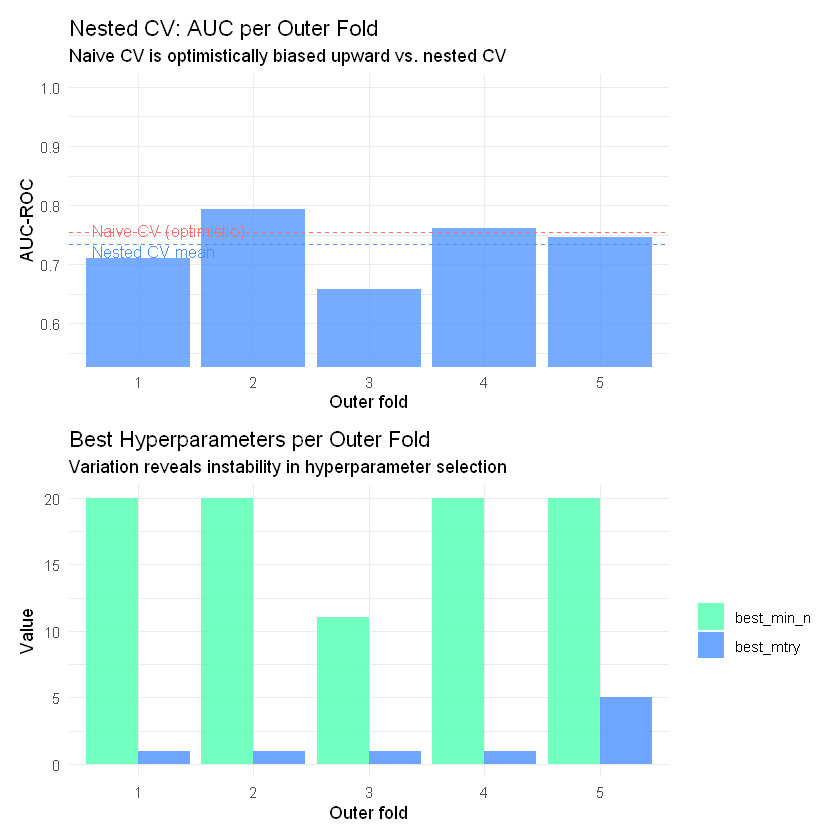

In [4]:
# Distribution of outer fold AUC estimates
p_folds <- ggplot(nested_auc_per_fold, aes(x=factor(outer_fold), y=auc)) +
  geom_col(fill="#4a8fff", alpha=0.75) +
  geom_hline(yintercept=nested_auc_mean, linetype="dashed", color="#4a8fff") +
  geom_hline(yintercept=naive_auc,       linetype="dashed", color="#ff6b6b") +
  annotate("text", x=0.6, y=naive_auc+0.005,
           label="Naive CV (optimistic)", color="#ff6b6b", hjust=0, size=3.5) +
  annotate("text", x=0.6, y=nested_auc_mean-0.01,
           label="Nested CV mean", color="#4a8fff", hjust=0, size=3.5) +
  labs(title="Nested CV: AUC per Outer Fold",
       subtitle="Naive CV is optimistically biased upward vs. nested CV",
       x="Outer fold", y="AUC-ROC") +
  coord_cartesian(ylim=c(0.55, 1.0)) +
  theme_minimal()

# Hyperparameter selections across outer folds
p_params <- nested_auc_per_fold %>%
  pivot_longer(c(best_mtry, best_min_n), names_to="param", values_to="value") %>%
  ggplot(aes(x=factor(outer_fold), y=value, fill=param)) +
  geom_col(position="dodge", alpha=0.8) +
  scale_fill_manual(values=c(best_mtry="#4a8fff", best_min_n="#4fffb0")) +
  labs(title="Best Hyperparameters per Outer Fold",
       subtitle="Variation reveals instability in hyperparameter selection",
       x="Outer fold", y="Value", fill=NULL) +
  theme_minimal()

(p_folds / p_params)

---

## Common Pitfalls

**1. Confusing the outer and inner CV performance estimates**  
The inner CV AUC is used to select hyperparameters — it is not the performance estimate. The outer CV AUC (mean over outer folds) is the unbiased estimate. Never report the inner CV performance as the result.

**2. Using nested CV to select a single set of hyperparameters**  
Nested CV estimates how well the *procedure* of tuning + fitting generalises — it does not identify the single best hyperparameter set. Different outer folds often select different hyperparameters (see the visualisation above). To deploy a model, rerun the inner CV procedure on the full dataset and use those hyperparameters.

**3. Skipping nested CV on large datasets**  
The absolute size of selection bias decreases as n grows, but it does not disappear. For publication or high-stakes applications, report nested CV regardless of sample size. The computational cost scales linearly with k_outer, so outer k=3 or k=5 is usually affordable.

**4. Using a test set inside the nested CV structure**  
The test set remains untouched throughout nested CV. The entire nested procedure — outer and inner loops — operates only on the training data. The test set is used exactly once, after all tuning and model selection are complete, to report the final performance.

**5. Expecting nested CV to eliminate all optimism**  
Nested CV removes the bias from hyperparameter selection but not from feature selection or structural model choices (which response distribution, which predictors to consider). If these were informed by the data, additional optimism remains.

---
*r_methods_library · Samantha McGarrigle · [github.com/samantha-mcgarrigle](https://github.com/samantha-mcgarrigle)*